# Synthetic CMAB — regime-matched fairness

This notebook runs and analyzes the synthetic contextual multi-armed bandit (CMAB) experiments used in the thesis. The objective is to evaluate whether fairness-aware bandit policies and Reweighting-based preprocessing improve fairness metrics without causing an excessive loss in predictive utility.

Three synthetic regimes are considered:

- **Stationary deterministic regime**: evaluated with LinUCB and FairLinUCB.
- **Stationary stochastic regime**: evaluated with Linear Thompson Sampling and FairLinTS.
- **Adversarial switching regime**: evaluated with EXP4 and FairEXP4.

For each regime, the notebook compares two preprocessing settings:

- **Uniform**: all observations receive equal update weight.
- **Reweighting**: observations are weighted according to their group–oracle-action stratum.

The main utility metrics are average reward and cumulative prediction error. Fairness is assessed using demographic parity (DP), equalized odds (EO), and UtilityGap.


### Imports and portable project setup

This cell loads the project modules and detects the repository root automatically. The notebook is intended to work from a fresh GitHub clone without hard-coded local paths.

Most implementation details are the `src/fair_bandits/` package:

- synthetic data generation and preprocessing weights are handled in `fair_bandits.data`;
- policy construction and replay are handled through `fair_bandits.policies` and `fair_bandits.experiments`;
- metric normalization and temporal loading are handled in `fair_bandits.metrics` and `fair_bandits.io`;
- figure generation is handled in `fair_bandits.plots`.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable
import platform
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import wilcoxon

def find_project_root(start: Path | None = None) -> Path:
    """
    Find the repository root from the current notebook location.

    This lets the notebook run both from VS Code and from Jupyter, whether the
    current working directory is the project root or a subfolder such as notebooks/.
    """
    current = Path.cwd().resolve() if start is None else Path(start).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "src" / "fair_bandits").exists():
            return candidate
        if (candidate / "fair_bandits").exists():
            return candidate

    return current


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from fair_bandits.config import build_config

from fair_bandits.data import (
    make_preprocessing_weights,
    make_synthetic_cmab_dataset,
    make_synthetic_expert_advice,
    make_synthetic_potential_rewards,
)

from fair_bandits.metrics import normalize_metric_columns

from fair_bandits.policies import SyntheticPolicyParams

from fair_bandits.experiments import (
    replay_one_synthetic_trajectory,
    run_online_synthetic_benchmarks,
)

from fair_bandits.io import (
    export_latex_table,
    fmt_mean_sd,
    load_downsampled_synthetic_temporal_logs,
)

from fair_bandits.plots import (
    plot_synthetic_inprocessing_fairness,
    plot_synthetic_performance_metric,
    plot_synthetic_preprocessing_fairness,
)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR if SRC_DIR.exists() else "not used")
print("Imports completed successfully.")

Python: 3.13.0 (tags/v3.13.0:60403a5, Oct  7 2024, 09:38:07) [MSC v.1941 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
PROJECT_ROOT: C:\Users\jmjn\Desktop\MA2\thesis\MA-Thesis
SRC_DIR: C:\Users\jmjn\Desktop\MA2\thesis\MA-Thesis\src
Imports completed successfully.


### Configuration

This section defines the experimental design and output locations.

The notebook can be run in two modes:

- **dev**: a short run used to check that the full pipeline works;
- **full**: the complete experiment used for thesis figures and tables.

The synthetic benchmark is organized by regime. Each regime is paired with the algorithm family that best matches its learning setting: LinUCB for deterministic environments, Thompson Sampling for stochastic environments, and EXP4 for adversarial expert-advice environments.

The output structure is also defined here. Raw trajectories and compact endpoint summaries are stored under the run directory, while final thesis-ready figures and tables are exported to separate `final_figures` and `tables` folders.

In [2]:
# Use "dev" first. Switch to "full" only after the preflight and dev run succeed.
RUN_MODE = "full"  # "dev" or "full"

try:
    CFG = build_config(
        run_mode="full" if RUN_MODE == "full" else "dev",
    )
except TypeError:
    CFG = build_config(
        "full" if RUN_MODE == "full" else "dev",
    )

RESULTS_ROOT = Path(CFG.results_dir)
SYNTHETIC_ROOT = RESULTS_ROOT / "synthetic_cmab_regime_matched_v2"
RUN_DIR = SYNTHETIC_ROOT / RUN_MODE

TRAJECTORY_DIR = RUN_DIR / "trajectories"
RAW_TABLE_DIR = RUN_DIR / "tables"
METADATA_DIR = RUN_DIR / "metadata"

FIG_DIR = RESULTS_ROOT / "final_figures" / "synthetic"
TABLE_DIR = RESULTS_ROOT / "tables" / "synthetic"

for directory in [
    RUN_DIR,
    TRAJECTORY_DIR,
    RAW_TABLE_DIR,
    METADATA_DIR,
    FIG_DIR,
    TABLE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

REGIMES = [
    "stationary_deterministic",
    "stationary_stochastic",
    "adversarial_switching",
]

PREPROCESSINGS = [
    "uniform",
    "reweigh_group_label",
]

POLICIES_BY_REGIME = {
    "stationary_deterministic": [
        "LinUCB",
        "FairLinUCB_DP",
    ],
    "stationary_stochastic": [
        "LinTS",
        "FairLinTS_DP",
    ],
    "adversarial_switching": [
        "EXP4",
        "FairEXP4_DP",
    ],
}

REGIME_LABELS = {
    "stationary_deterministic": "Stationary deterministic",
    "stationary_stochastic": "Stationary stochastic",
    "adversarial_switching": "Adversarial switching",
}

REGIME_FILE_TAGS = {
    "stationary_deterministic": "deterministic",
    "stationary_stochastic": "stochastic",
    "adversarial_switching": "adversarial",
}

POLICY_LABELS = {
    "LinUCB": "LinUCB",
    "FairLinUCB_DP": "FairLinUCB",
    "LinTS": "LinTS",
    "FairLinTS_DP": "FairLinTS",
    "EXP4": "EXP4",
    "FairEXP4_DP": "FairEXP4",
}

PREPROCESSING_LABELS = {
    "uniform": "Uniform",
    "reweigh_group_label": "Reweighting",
}

def friendly_policy(policy: str) -> str:
    """
    Display label for policy names in tables.
    """
    return POLICY_LABELS.get(str(policy), str(policy))


def friendly_preprocessing(preprocessing: str) -> str:
    """
    Display label for preprocessing names in tables.
    """
    return PREPROCESSING_LABELS.get(str(preprocessing), str(preprocessing))

if RUN_MODE == "dev":
    T_MAX = 1000
    CHECKPOINTS = [250, 500, 1000]
    SEEDS = [0, 1]
else:
    T_MAX = 5000
    CHECKPOINTS = [500, 1000, 2000, 5000]
    SEEDS = list(range(int(getattr(CFG, "n_seeds", 50))))

D = 10
N_EXPERTS = 6

# Policy hyperparameters: preserved from the original synthetic notebooks.
ALPHA_LINUCB = 1.5
LAMBDA_RIDGE = 1.0
TS_V = 0.5
EXP4_GAMMA = 0.07

DP_TAU = 0.02
DP_LAMBDA_LINEAR = 2.0
DP_LAMBDA_EXP4 = 0.20
BETA_SMOOTH = 1.0
MIN_GROUP_COUNT = 20

PLOT_EVERY = 10
ZOOM_START = 250

# Preserve existing trajectories unless an explicit rerun is requested.
FORCE_RERUN = False

# Keep False until the preflight cell has succeeded.
RUN_PREFLIGHT = True
RUN_BENCHMARK = True

ENDPOINT_PATH = RAW_TABLE_DIR / "endpoint_perseed.csv"
RUN_INDEX_PATH = RAW_TABLE_DIR / "run_index.csv"

print("RUN_MODE:", RUN_MODE)
print("RUN_DIR:", RUN_DIR)
print("T_MAX:", T_MAX)
print("CHECKPOINTS:", CHECKPOINTS)
print("Number of seeds:", len(SEEDS))
print("FORCE_RERUN:", FORCE_RERUN)
print("RUN_BENCHMARK:", RUN_BENCHMARK)

RUN_MODE: full
RUN_DIR: results\full\synthetic_cmab_regime_matched_v2\full
T_MAX: 5000
CHECKPOINTS: [500, 1000, 2000, 5000]
Number of seeds: 50
FORCE_RERUN: False
RUN_BENCHMARK: True


### Preflight

The preflight is a small sanity check before running or loading the full benchmark. For each synthetic regime, it generates a short environment, computes the Reweighting support table, and replays one fairness-aware policy.

This step checks that:

- the synthetic generator works for all regimes;
- group and oracle-action strata are correctly represented;
- Reweighting weights are well-defined;
- EXP4 expert advice is correctly generated for the adversarial regime;
- the replay function produces the expected temporal metrics.

In [3]:
def run_preflight() -> None:
    """
    Run preflight checks for each regime.
    This generates a small synthetic dataset for each regime and runs a single trajectory replay to ensure that the code runs without errors.
    """
    
    for regime in REGIMES:
        print("Preflight regime:", regime)

        dataset = make_synthetic_cmab_dataset(
            T=250,
            d=D,
            regime=regime,
            seed=42,
        )

        groups = np.asarray(dataset["group"]).astype(str)
        oracle_actions = np.asarray(dataset["y_opt"], dtype=int)

        print("Groups:", np.unique(groups, return_counts=True))

        _, support = make_preprocessing_weights(
            preprocessing="reweigh_group_label",
            groups=groups,
            oracle_actions=oracle_actions,
        )

        print("\nReweighting support:")
        display(support)

        expert_advice = None

        if regime == "adversarial_switching":
            expert_advice, expert_names = make_synthetic_expert_advice(
                dataset,
                n_experts=N_EXPERTS,
                seed=42,
            )

            print("Expert advice shape:", expert_advice.shape)
            print("Expert names:", expert_names)

        policy_name = POLICIES_BY_REGIME[regime][1]

        potential_rewards = make_synthetic_potential_rewards(
            dataset,
            environment_seed=42,
            regime=regime,
        )

        params = SyntheticPolicyParams(
            d=D,
            alpha_linucb=ALPHA_LINUCB,
            lambda_ridge=LAMBDA_RIDGE,
            ts_v=TS_V,
            exp4_gamma=EXP4_GAMMA,
            dp_tau=DP_TAU,
            dp_lambda_linear=DP_LAMBDA_LINEAR,
            dp_lambda_exp4=DP_LAMBDA_EXP4,
            beta_smooth=BETA_SMOOTH,
            min_group_count=MIN_GROUP_COUNT,
            n_experts=N_EXPERTS,
        )

        logs_df, _ = replay_one_synthetic_trajectory(
            dataset=dataset,
            potential_rewards=potential_rewards,
            policy_name=policy_name,
            preprocessing="reweigh_group_label",
            seed=42,
            params=params,
            expert_advice=expert_advice,
        )

        print("Replay rows:", len(logs_df))
        print("Final metrics:")

        display(
            logs_df[
                [
                    "avg_reward",
                    "cumulative_prediction_error",
                    "DP_gap_over_time",
                    "EO_gap_over_time",
                    "UtilityGap_over_time",
                ]
            ].tail(1)
        )

    print("\nPreflight completed successfully.")


if RUN_PREFLIGHT:
    run_preflight()
else:
    print("Preflight skipped because RUN_PREFLIGHT is False.")

Preflight regime: stationary_deterministic
Groups: (array(['0', '1'], dtype='<U21'), array([132, 118]))

Reweighting support:


,group,oracle_action,n,raw_weight,normalized_weight
0,0,0,81,0.771605,0.771605
1,0,1,51,1.225490,1.225490
2,1,0,80,0.781250,0.781250
3,1,1,38,1.644737,1.644737


Replay rows: 250
Final metrics:


,avg_reward,cumulative_prediction_error,DP_gap_over_time,EO_gap_over_time,UtilityGap_over_time
249,0.744,28.0,0.069081,0.103704,0.125064


Preflight regime: stationary_stochastic
Groups: (array(['0', '1'], dtype='<U21'), array([132, 118]))

Reweighting support:


...

Preflight regime: adversarial_switching
Groups: (array(['0', '1'], dtype='<U21'), array([132, 118]))

Reweighting support:


,group,oracle_action,n,raw_weight,normalized_weight
0,0,0,54,1.157407,1.157407
1,0,1,78,0.801282,0.801282
2,1,0,46,1.358696,1.358696
3,1,1,72,0.868056,0.868056


Expert advice shape: (250, 6, 2)
Expert names: ['oracle_like', 'noisy_oracle', 'group0_positive_bias', 'group1_positive_bias', 'conservative_action0', 'random']
Replay rows: 250
Final metrics:


,avg_reward,cumulative_prediction_error,DP_gap_over_time,EO_gap_over_time,UtilityGap_over_time
249,0.692,39.762297,0.063688,0.112179,0.106831



Preflight completed successfully.


### Launch or reload benchmark outputs

This cell either runs the synthetic benchmark or reloads existing outputs.

When `RUN_BENCHMARK = True`, the benchmark evaluates all combinations of:

- regime;
- preprocessing method;
- regime-matched policy;
- random seed;
- evaluation checkpoint.

For each trajectory, the benchmark stores a compressed temporal log. It also exports two compact files:

- `endpoint_perseed.csv`: one row per seed and checkpoint, used for tables and statistical tests;
- `run_index.csv`: an index of generated trajectories, used to reload temporal curves efficiently.

When `RUN_BENCHMARK = False`, the notebook reloads these files instead of recomputing the benchmark.

In [4]:
params = SyntheticPolicyParams(
    d=D,
    alpha_linucb=ALPHA_LINUCB,
    lambda_ridge=LAMBDA_RIDGE,
    ts_v=TS_V,
    exp4_gamma=EXP4_GAMMA,
    dp_tau=DP_TAU,
    dp_lambda_linear=DP_LAMBDA_LINEAR,
    dp_lambda_exp4=DP_LAMBDA_EXP4,
    beta_smooth=BETA_SMOOTH,
    min_group_count=MIN_GROUP_COUNT,
    n_experts=N_EXPERTS,
)

if RUN_BENCHMARK:
    endpoint_df, run_index_df = run_online_synthetic_benchmarks(
        run_dir=RUN_DIR,
        regimes=REGIMES,
        preprocessings=PREPROCESSINGS,
        policies_by_regime=POLICIES_BY_REGIME,
        seeds=SEEDS,
        checkpoints=CHECKPOINTS,
        t_max=T_MAX,
        params=params,
        force_rerun=FORCE_RERUN,
    )

    endpoint_df = normalize_metric_columns(endpoint_df)

    print("\nEndpoint rows:", len(endpoint_df))
    print("Run-index rows:", len(run_index_df))

    print("\nEndpoint preview:")
    print(endpoint_df.head().to_string(index=False))

    print("\nRun-index preview:")
    print(run_index_df.head().to_string(index=False))

else:
    print(
        "Benchmark generation is disabled. "
        "Set RUN_BENCHMARK = True in the configuration cell when ready."
    )

    if ENDPOINT_PATH.exists() and RUN_INDEX_PATH.exists():
        endpoint_df = normalize_metric_columns(pd.read_csv(ENDPOINT_PATH))
        run_index_df = pd.read_csv(RUN_INDEX_PATH)

        print("\nLoaded existing outputs:")
        print("endpoint_df:", endpoint_df.shape)
        print("run_index_df:", run_index_df.shape)

        print("\nEndpoint preview:")
        print(endpoint_df.head().to_string(index=False))

        print("\nRun-index preview:")
        print(run_index_df.head().to_string(index=False))

    else:
        print("\nNo existing benchmark outputs found yet.")
        print("ENDPOINT_PATH:", ENDPOINT_PATH)
        print("RUN_INDEX_PATH:", RUN_INDEX_PATH)

Regime: stationary_deterministic
Running: {'regime': 'stationary_deterministic', 'preprocessing': 'uniform', 'policy': 'LinUCB', 'seed': 0}
Completed 1/600
Running: {'regime': 'stationary_deterministic', 'preprocessing': 'uniform', 'policy': 'FairLinUCB_DP', 'seed': 0}
Completed 2/600
Running: {'regime': 'stationary_deterministic', 'preprocessing': 'reweigh_group_label', 'policy': 'LinUCB', 'seed': 0}
Completed 3/600
Running: {'regime': 'stationary_deterministic', 'preprocessing': 'reweigh_group_label', 'policy': 'FairLinUCB_DP', 'seed': 0}
Completed 4/600
Running: {'regime': 'stationary_deterministic', 'preprocessing': 'uniform', 'policy': 'LinUCB', 'seed': 1}
Completed 5/600
Running: {'regime': 'stationary_deterministic', 'preprocessing': 'uniform', 'policy': 'FairLinUCB_DP', 'seed': 1}
Completed 6/600
Running: {'regime': 'stationary_deterministic', 'preprocessing': 'reweigh_group_label', 'policy': 'LinUCB', 'seed': 1}
Completed 7/600
Running: {'regime': 'stationary_deterministic', '

### Validate compact output files

This section checks that the benchmark outputs have the expected structure before any figures or tables are produced.

The validation verifies:

- the number of rows in the endpoint and run-index files;
- the list of regimes, policies, preprocessings, seeds, and checkpoints;
- the presence of key utility and fairness columns;
- compatibility with the thesis terminology, in particular `cumulative_prediction_error`.


In [5]:
if "endpoint_df" not in globals() or "run_index_df" not in globals():
    raise RuntimeError(
        "No endpoint/run-index data available. "
        "Run the benchmark first, or point RUN_DIR to existing outputs."
    )

endpoint_df = normalize_metric_columns(endpoint_df)

print("endpoint_df shape:", endpoint_df.shape)
print("run_index_df shape:", run_index_df.shape)
print("\nRegimes:", sorted(endpoint_df["regime"].unique()))
print("Preprocessings:", sorted(endpoint_df["preprocessing"].unique()))
print("Policies:", sorted(endpoint_df["policy"].unique()))
print("Seeds:", endpoint_df["seed"].nunique())
print("Checkpoints:", sorted(endpoint_df["T"].unique()))

expected_endpoint_rows = (
    len(REGIMES)
    * len(PREPROCESSINGS)
    * 2
    * len(SEEDS)
    * len(CHECKPOINTS)
)

expected_run_rows = (
    len(REGIMES)
    * len(PREPROCESSINGS)
    * 2
    * len(SEEDS)
)

print("\nExpected endpoint rows:", expected_endpoint_rows)
print("Observed endpoint rows:", len(endpoint_df))
print("Expected run-index rows:", expected_run_rows)
print("Observed run-index rows:", len(run_index_df))

required_endpoint_cols = [
    "regime",
    "preprocessing",
    "policy",
    "seed",
    "T",
    "accuracy",
    "avg_reward",
    "cumulative_prediction_error",
    "DP_gap",
    "EO_gap",
    "UtilityGap",
]

missing_endpoint_cols = [
    column
    for column in required_endpoint_cols
    if column not in endpoint_df.columns
]

if missing_endpoint_cols:
    raise ValueError(f"Missing endpoint columns: {missing_endpoint_cols}")

if len(endpoint_df) != expected_endpoint_rows:
    print(
        "Warning: endpoint row count differs from the expected run. "
        "Inspect the file before using the tables in the thesis."
    )

if len(run_index_df) != expected_run_rows:
    print(
        "Warning: run-index row count differs from the expected run. "
        "Inspect the file before using the figures in the thesis."
    )

display(endpoint_df.head())
display(run_index_df.head())

endpoint_df shape: (2400, 17)
run_index_df shape: (600, 7)

Regimes: ['adversarial_switching', 'stationary_deterministic', 'stationary_stochastic']
Preprocessings: ['reweigh_group_label', 'uniform']
Policies: ['EXP4', 'FairEXP4_DP', 'FairLinTS_DP', 'FairLinUCB_DP', 'LinTS', 'LinUCB']
Seeds: 50
Checkpoints: [np.int64(500), np.int64(1000), np.int64(2000), np.int64(5000)]

Expected endpoint rows: 2400
Observed endpoint rows: 2400
Expected run-index rows: 600
Observed run-index rows: 600


,regime,preprocessing,policy,seed,T,n_observed,accuracy,avg_reward,average_reward,cum_reward,cumulative_prediction_error,DP_gap,TPR_gap,FPR_gap,EO_gap,UtilityGap,trajectory_file
0,stationary_deterministic,uniform,LinUCB,0,500,500,0.7240,0.8340,0.8340,417.0,56.0,0.063939,0.190713,0.052593,0.190713,0.008058,results\full\synthetic_cmab_regime_matched_v2\...
1,stationary_deterministic,uniform,LinUCB,0,1000,1000,0.7590,0.8530,0.8530,853.0,98.0,0.055780,0.135746,0.108354,0.135746,0.000352,results\full\synthetic_cmab_regime_matched_v2\...
2,stationary_deterministic,uniform,LinUCB,0,2000,2000,0.8000,0.8705,0.8705,1741.0,154.0,0.031685,0.098810,0.077601,0.098810,0.031853,results\full\synthetic_cmab_regime_matched_v2\...
3,stationary_deterministic,uniform,LinUCB,0,5000,5000,0.8358,0.8908,0.8908,4454.0,295.0,0.015992,0.081393,0.074912,0.081393,0.035462,results\full\synthetic_cmab_regime_matched_v2\...
4,stationary_deterministic,uniform,FairLinUCB_DP,0,500,500,0.6740,0.8080,0.8080,404.0,69.0,0.004870,0.148972,0.037778,0.148972,0.013842,results\full\synthetic_cmab_regime_matched_v2\...


,regime,preprocessing,policy,seed,trajectory_file,status,elapsed_seconds
0,stationary_deterministic,uniform,LinUCB,0,results\full\synthetic_cmab_regime_matched_v2\...,computed,4.185528
1,stationary_deterministic,uniform,FairLinUCB_DP,0,results\full\synthetic_cmab_regime_matched_v2\...,computed,4.541392
2,stationary_deterministic,reweigh_group_label,LinUCB,0,results\full\synthetic_cmab_regime_matched_v2\...,computed,4.140705
3,stationary_deterministic,reweigh_group_label,FairLinUCB_DP,0,results\full\synthetic_cmab_regime_matched_v2\...,computed,4.516261
4,stationary_deterministic,uniform,LinUCB,1,results\full\synthetic_cmab_regime_matched_v2\...,computed,4.681595


### Load downsampled temporal trajectories


In [6]:
temporal_df = load_downsampled_synthetic_temporal_logs(
    run_index_df,
    run_dir=RUN_DIR,
    plot_every=PLOT_EVERY,
)

print("\ntemporal_df shape:", temporal_df.shape)

print(
    "Rows per trajectory:",
    temporal_df.groupby(
        ["regime", "preprocessing", "policy", "seed"]
    ).size().unique(),
)

print(temporal_df.head().to_string(index=False))

Loaded 100/600 trajectories
Loaded 200/600 trajectories
Loaded 300/600 trajectories
Loaded 400/600 trajectories
Loaded 500/600 trajectories
Loaded 600/600 trajectories

temporal_df shape: (300000, 11)
Rows per trajectory: [500]
 t  avg_reward  cumulative_prediction_error  cumulative_regret  DP_gap_over_time  EO_gap_over_time  UtilityGap_over_time                   regime preprocessing policy  seed
10    0.400000                          5.0                5.0          0.416667          0.666667              0.166667 stationary_deterministic       uniform LinUCB     0
20    0.600000                          6.0                6.0          0.212121          0.800000              0.121212 stationary_deterministic       uniform LinUCB     0
30    0.666667                          8.0                8.0          0.400000          0.690476              0.133333 stationary_deterministic       uniform LinUCB     0
40    0.675000                         11.0               11.0          0.451128

### Generate figures

For each regime, five figures are produced:

1. **Preprocessing fairness comparison**: DP and EO gaps for uniform versus Reweighting.
2. **In-processing fairness comparison**: baseline versus fairness-aware policy under uniform preprocessing.
3. **Average reward over time**.
4. **Cumulative prediction error over time**.
5. **UtilityGap over time**.

The figures focus on the learning dynamics after the initial warm-up period, to interpret and avoids over-emphasizing early instability in the first rounds.

Generating figures for: stationary_deterministic
Saved: results\full\final_figures\synthetic\synthetic_deterministic_preprocessing_fairness.png


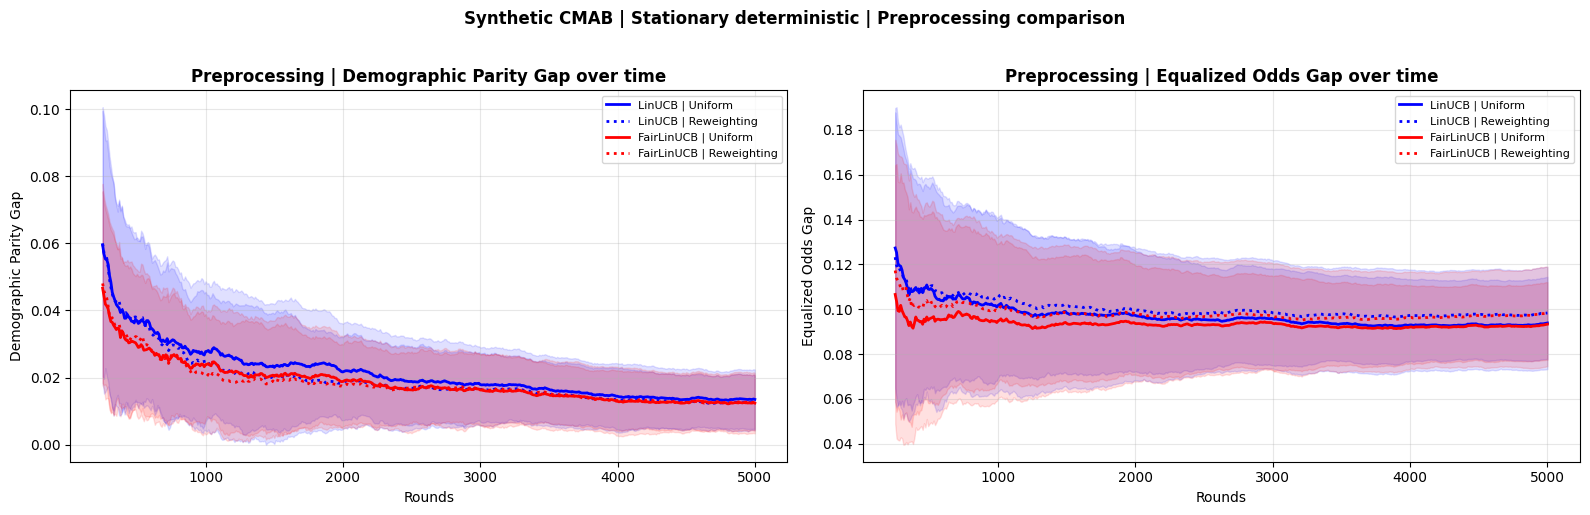

Saved: results\full\final_figures\synthetic\synthetic_deterministic_inprocessing_fairness.png


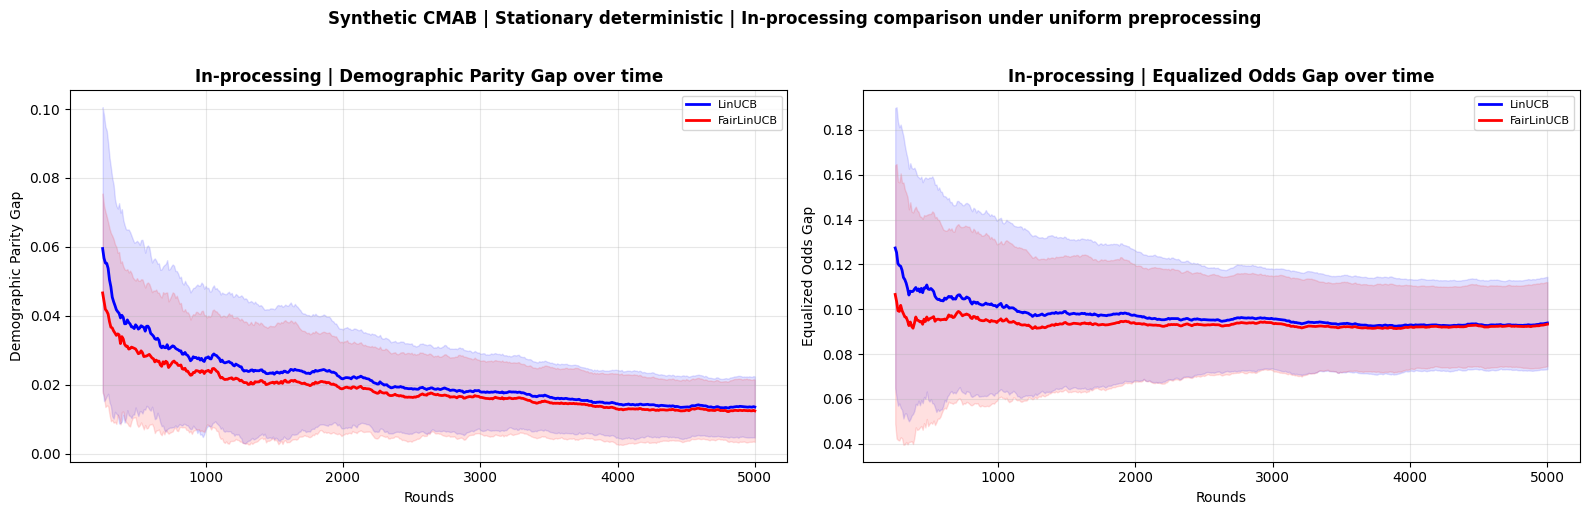

Saved: results\full\final_figures\synthetic\synthetic_deterministic_average_reward.png


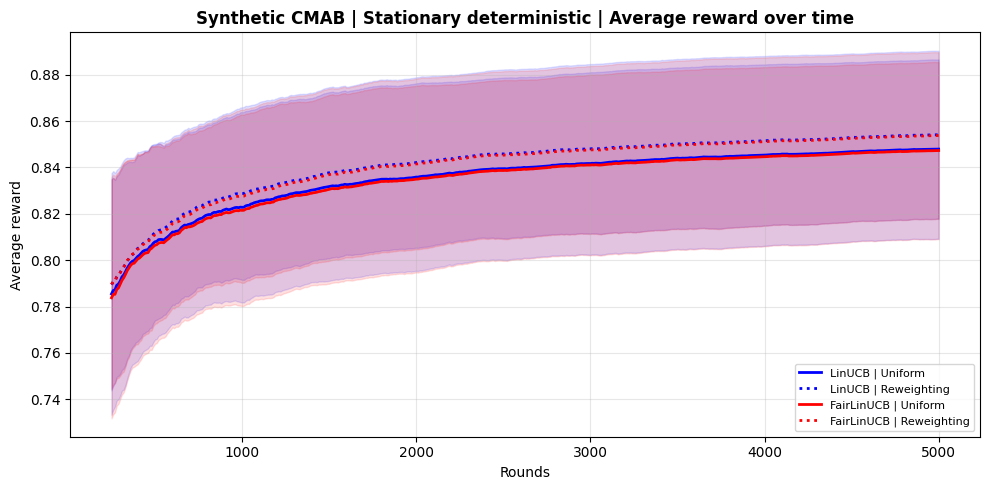

Saved: results\full\final_figures\synthetic\synthetic_deterministic_cumulative_prediction_error.png


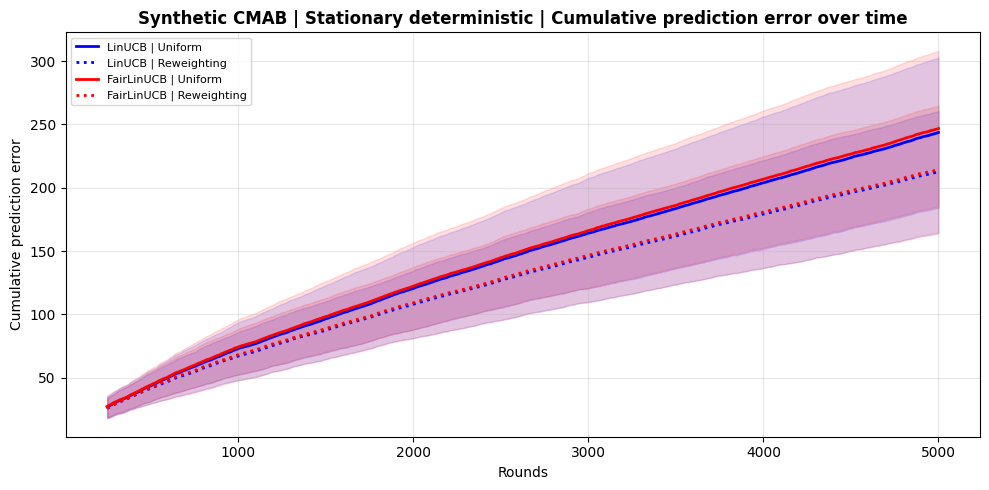

Saved: results\full\final_figures\synthetic\synthetic_deterministic_utility_gap.png


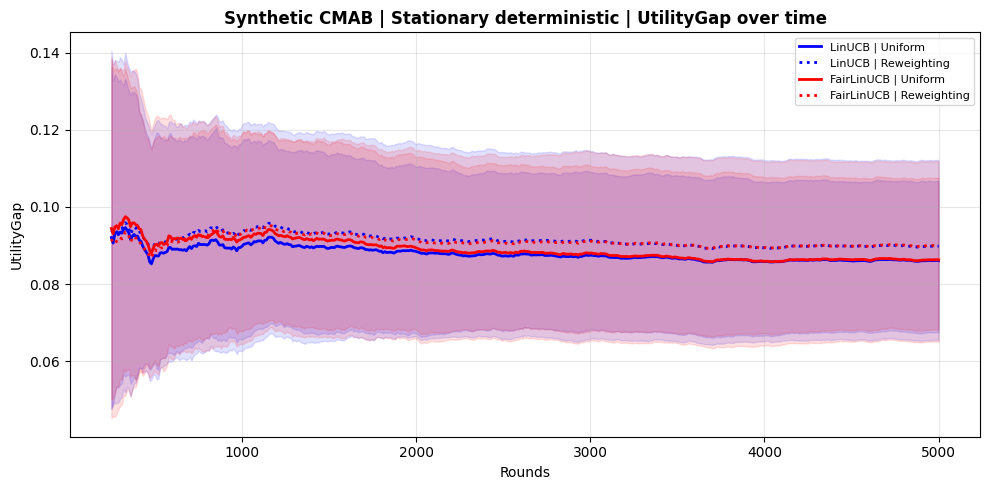

Generating figures for: stationary_stochastic
Saved: results\full\final_figures\synthetic\synthetic_stochastic_preprocessing_fairness.png


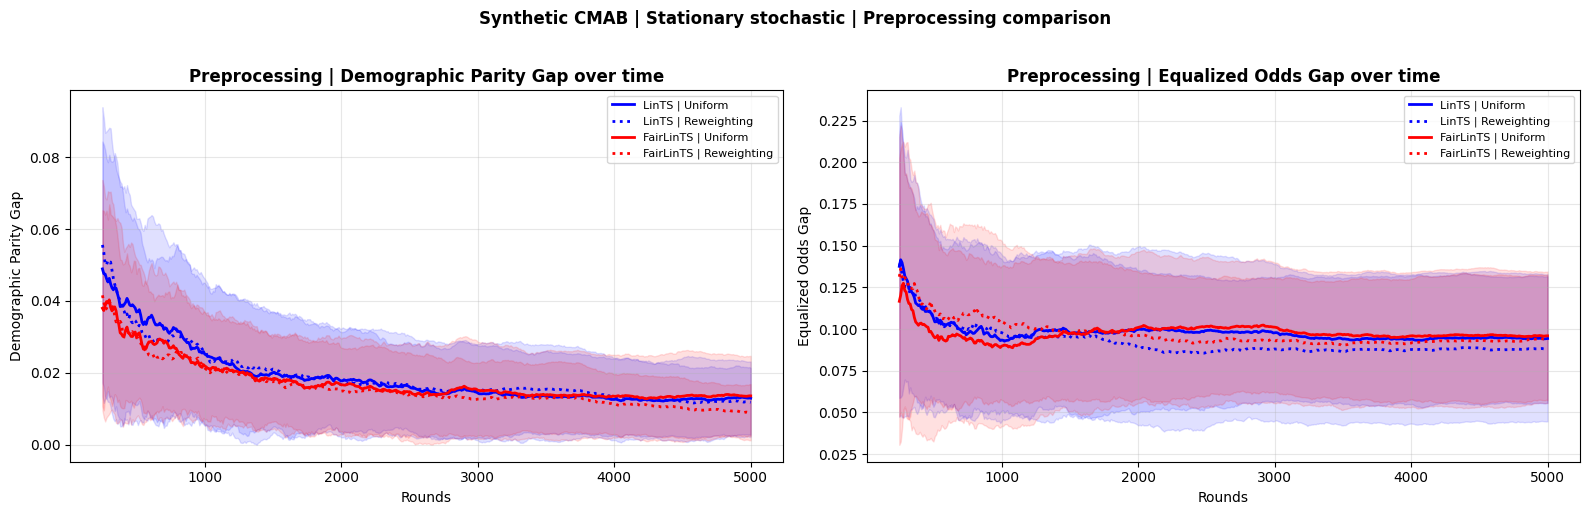

Saved: results\full\final_figures\synthetic\synthetic_stochastic_inprocessing_fairness.png


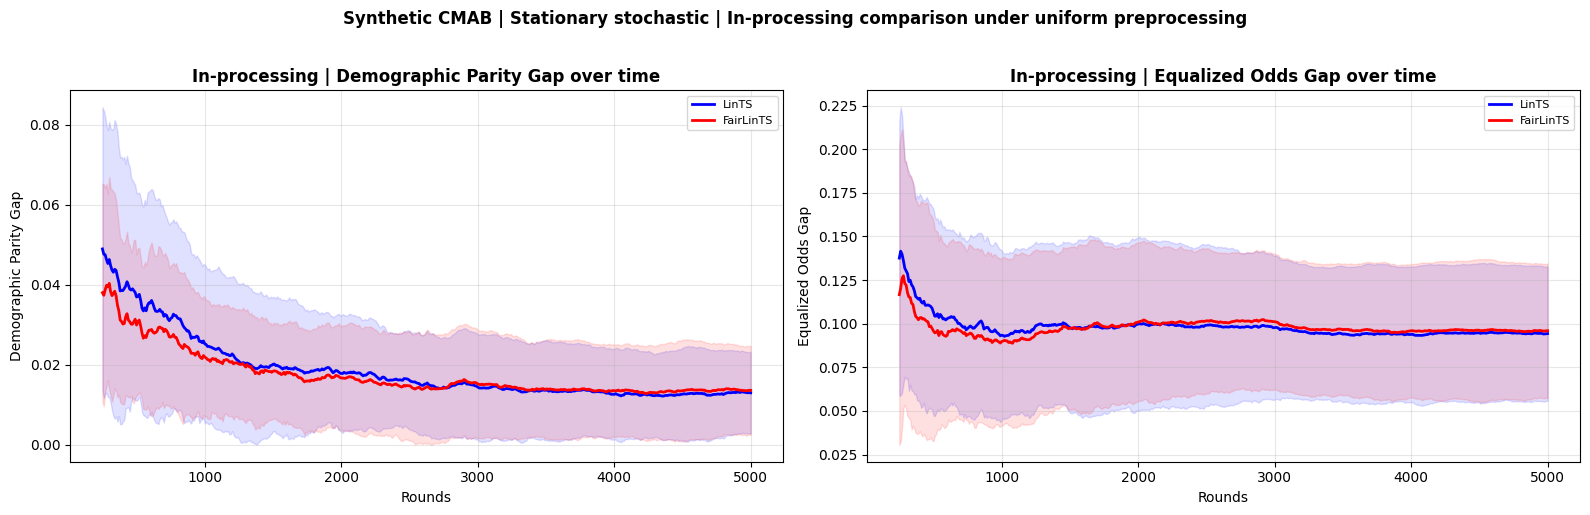

Saved: results\full\final_figures\synthetic\synthetic_stochastic_average_reward.png


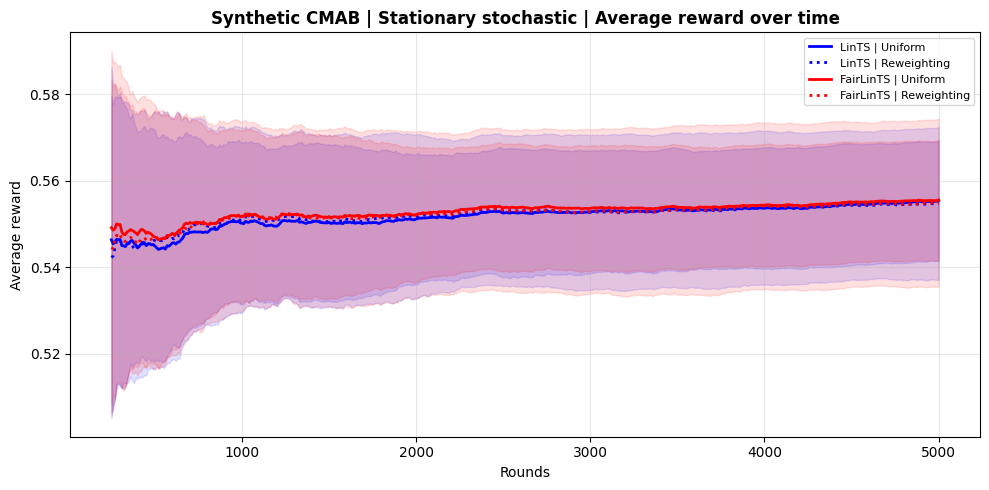

Saved: results\full\final_figures\synthetic\synthetic_stochastic_cumulative_prediction_error.png


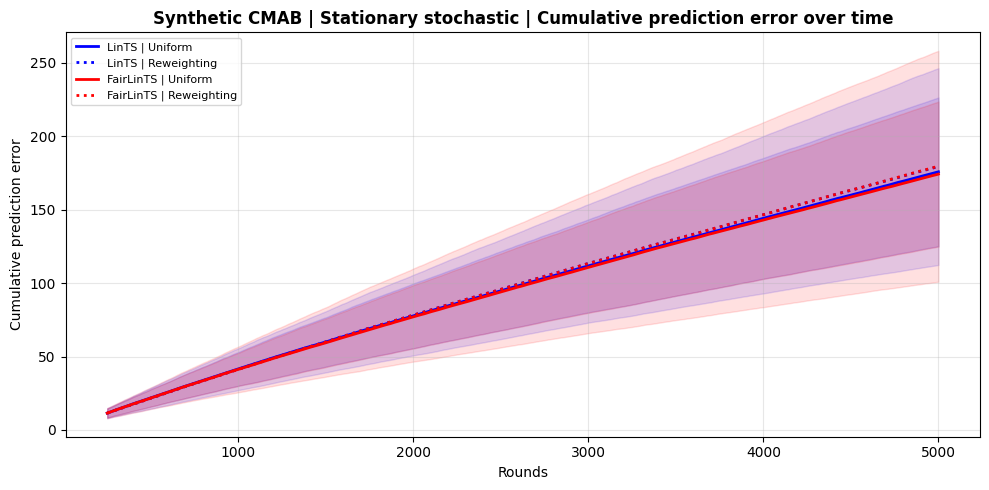

Saved: results\full\final_figures\synthetic\synthetic_stochastic_utility_gap.png


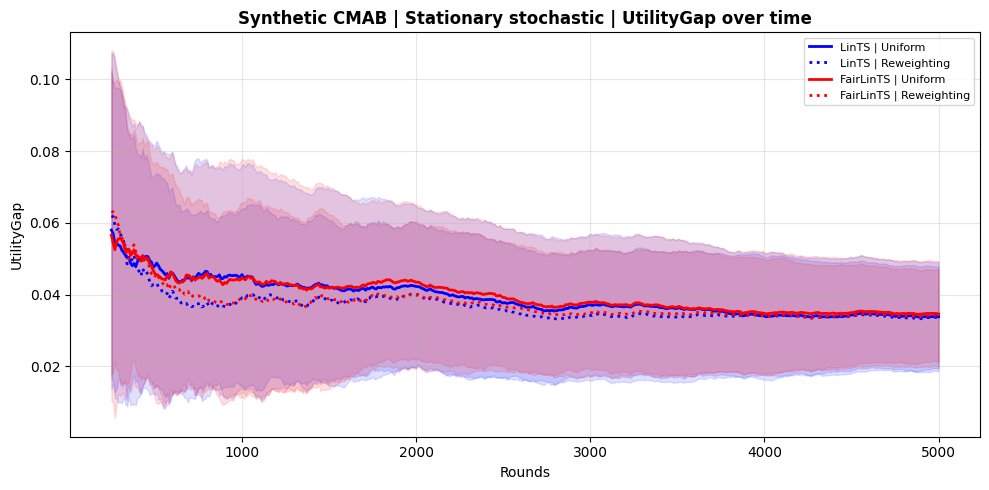

Generating figures for: adversarial_switching
Saved: results\full\final_figures\synthetic\synthetic_adversarial_preprocessing_fairness.png


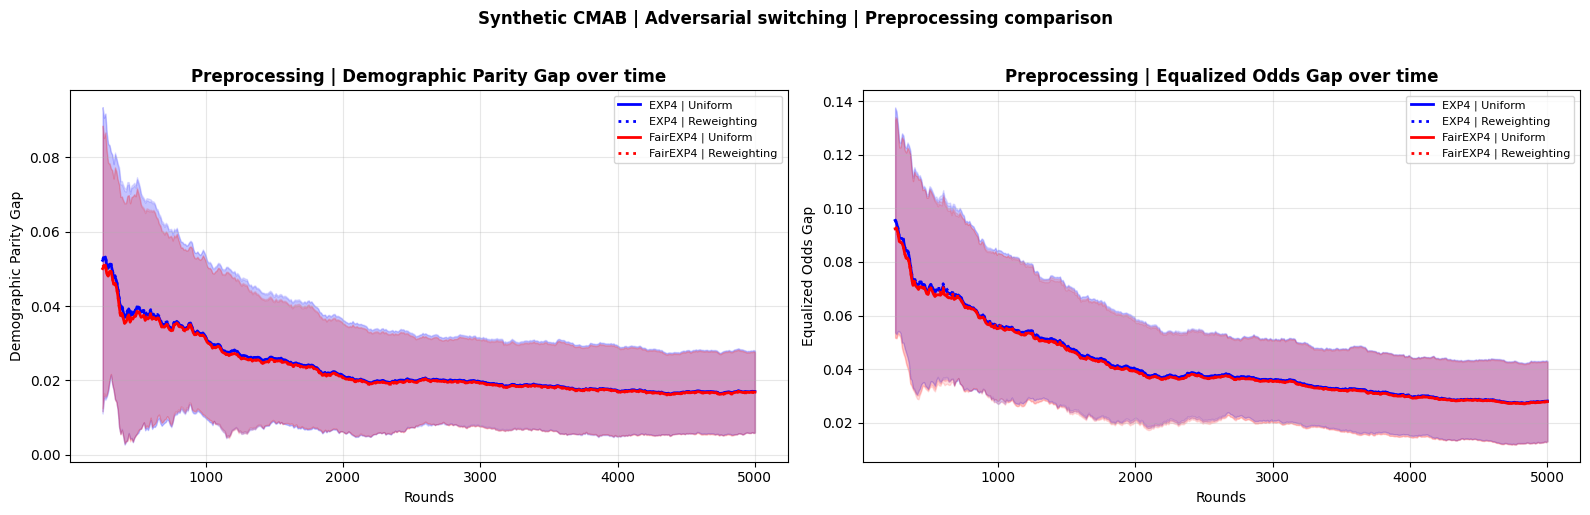

Saved: results\full\final_figures\synthetic\synthetic_adversarial_inprocessing_fairness.png


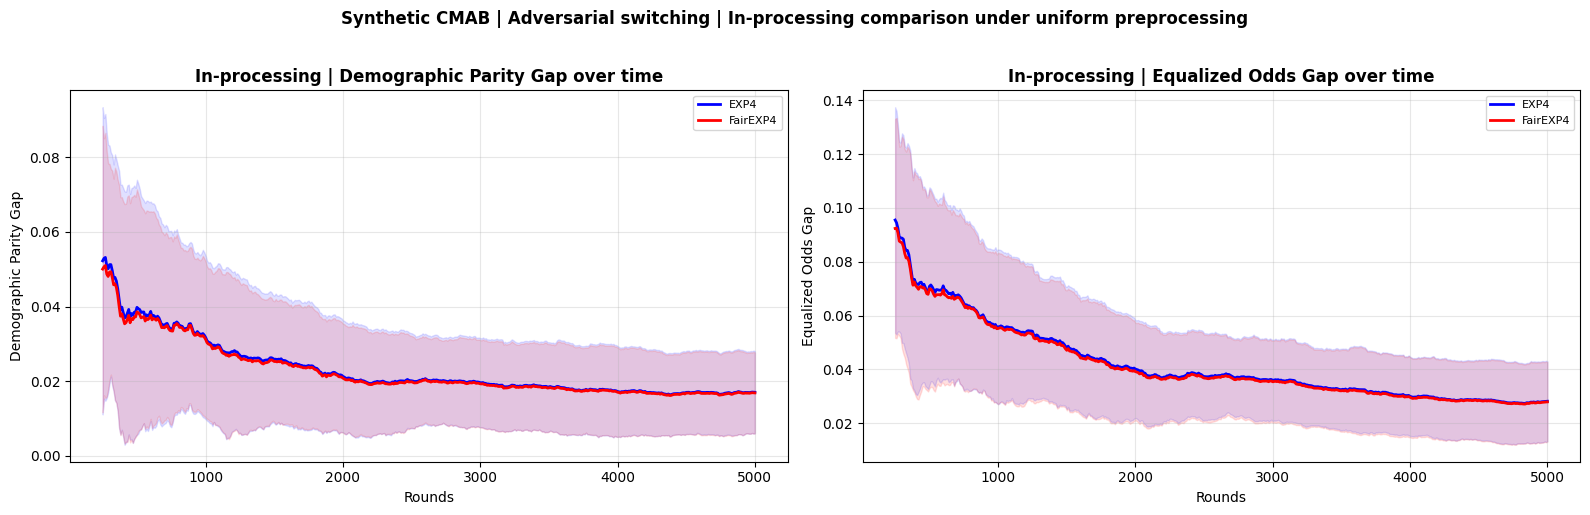

Saved: results\full\final_figures\synthetic\synthetic_adversarial_average_reward.png


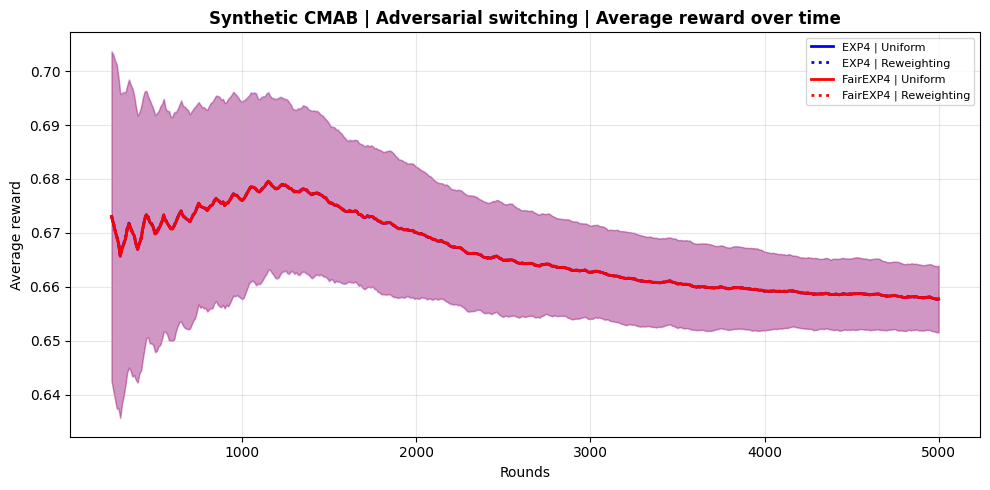

Saved: results\full\final_figures\synthetic\synthetic_adversarial_cumulative_prediction_error.png


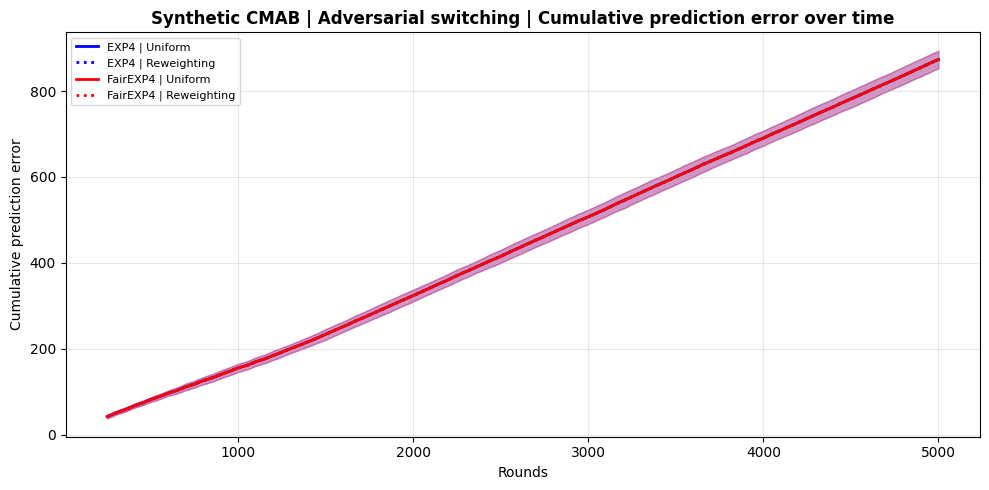

Saved: results\full\final_figures\synthetic\synthetic_adversarial_utility_gap.png


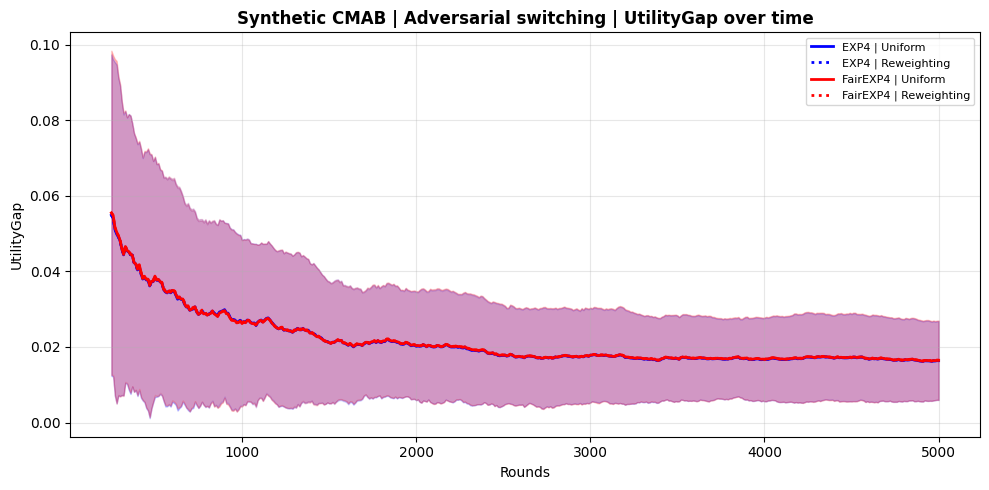


Generated figures: 15
results\full\final_figures\synthetic\synthetic_deterministic_preprocessing_fairness.png
results\full\final_figures\synthetic\synthetic_deterministic_inprocessing_fairness.png
results\full\final_figures\synthetic\synthetic_deterministic_average_reward.png
results\full\final_figures\synthetic\synthetic_deterministic_cumulative_prediction_error.png
results\full\final_figures\synthetic\synthetic_deterministic_utility_gap.png
results\full\final_figures\synthetic\synthetic_stochastic_preprocessing_fairness.png
results\full\final_figures\synthetic\synthetic_stochastic_inprocessing_fairness.png
results\full\final_figures\synthetic\synthetic_stochastic_average_reward.png
results\full\final_figures\synthetic\synthetic_stochastic_cumulative_prediction_error.png
results\full\final_figures\synthetic\synthetic_stochastic_utility_gap.png
results\full\final_figures\synthetic\synthetic_adversarial_preprocessing_fairness.png
results\full\final_figures\synthetic\synthetic_adversari

In [7]:
figure_paths = []

for regime in REGIMES:
    print("Generating figures for:", regime)

    policies = POLICIES_BY_REGIME[regime]

    figure_paths.append(
        plot_synthetic_preprocessing_fairness(
            temporal_df,
            regime=regime,
            output_dir=FIG_DIR,
            policies=policies,
            preprocessings=PREPROCESSINGS,
            regime_label=REGIME_LABELS[regime],
            regime_file_tag=REGIME_FILE_TAGS[regime],
            policy_labels=POLICY_LABELS,
            preprocessing_labels=PREPROCESSING_LABELS,
            zoom_start=ZOOM_START,
            show=True,
        )
    )

    figure_paths.append(
        plot_synthetic_inprocessing_fairness(
            temporal_df,
            regime=regime,
            output_dir=FIG_DIR,
            policies=policies,
            regime_label=REGIME_LABELS[regime],
            regime_file_tag=REGIME_FILE_TAGS[regime],
            policy_labels=POLICY_LABELS,
            zoom_start=ZOOM_START,
            show=True,
        )
    )

    figure_paths.append(
        plot_synthetic_performance_metric(
            temporal_df,
            regime=regime,
            metric_col="avg_reward",
            ylabel="Average reward",
            filename_suffix="average_reward",
            output_dir=FIG_DIR,
            policies=policies,
            preprocessings=PREPROCESSINGS,
            regime_label=REGIME_LABELS[regime],
            regime_file_tag=REGIME_FILE_TAGS[regime],
            policy_labels=POLICY_LABELS,
            preprocessing_labels=PREPROCESSING_LABELS,
            zoom_start=ZOOM_START,
            show=True,
        )
    )

    figure_paths.append(
        plot_synthetic_performance_metric(
            temporal_df,
            regime=regime,
            metric_col="cumulative_prediction_error",
            ylabel="Cumulative prediction error",
            filename_suffix="cumulative_prediction_error",
            output_dir=FIG_DIR,
            policies=policies,
            preprocessings=PREPROCESSINGS,
            regime_label=REGIME_LABELS[regime],
            regime_file_tag=REGIME_FILE_TAGS[regime],
            policy_labels=POLICY_LABELS,
            preprocessing_labels=PREPROCESSING_LABELS,
            zoom_start=ZOOM_START,
            show=True,
        )
    )

    figure_paths.append(
        plot_synthetic_performance_metric(
            temporal_df,
            regime=regime,
            metric_col="UtilityGap_over_time",
            ylabel="UtilityGap",
            filename_suffix="utility_gap",
            output_dir=FIG_DIR,
            policies=policies,
            preprocessings=PREPROCESSINGS,
            regime_label=REGIME_LABELS[regime],
            regime_file_tag=REGIME_FILE_TAGS[regime],
            policy_labels=POLICY_LABELS,
            preprocessing_labels=PREPROCESSING_LABELS,
            zoom_start=ZOOM_START,
            show=True,
        )
    )

print("\nGenerated figures:", len(figure_paths))

for path in figure_paths:
    print(path)

### Final endpoint data

This cell extracts the final checkpoint from the compact endpoint table.

The final checkpoint corresponds to the last evaluation horizon of the selected run mode. It is used for summary tables and paired statistical tests.

At this stage, each row represents one seed for one combination of regime, preprocessing, and policy.

In [8]:
FINAL_T = int(endpoint_df["T"].max())

final_endpoint_df = endpoint_df[endpoint_df["T"] == FINAL_T].copy()
final_endpoint_df = normalize_metric_columns(final_endpoint_df)

print("FINAL_T:", FINAL_T)
print("Final endpoint rows:", len(final_endpoint_df))
print("Seeds:", final_endpoint_df["seed"].nunique())

display(final_endpoint_df.head())

FINAL_T: 5000
Final endpoint rows: 600
Seeds: 50


,regime,preprocessing,policy,seed,T,n_observed,accuracy,avg_reward,average_reward,cum_reward,cumulative_prediction_error,DP_gap,TPR_gap,FPR_gap,EO_gap,UtilityGap,trajectory_file
3,stationary_deterministic,uniform,LinUCB,0,5000,5000,0.8358,0.8908,0.8908,4454.0,295.0,0.015992,0.081393,0.074912,0.081393,0.035462,results\full\synthetic_cmab_regime_matched_v2\...
7,stationary_deterministic,uniform,FairLinUCB_DP,0,5000,5000,0.8152,0.8774,0.8774,4387.0,362.0,0.003591,0.056662,0.065393,0.065393,0.049494,results\full\synthetic_cmab_regime_matched_v2\...
11,stationary_deterministic,reweigh_group_label,LinUCB,0,5000,5000,0.8636,0.9050,0.9050,4525.0,224.0,0.018790,0.071384,0.097234,0.097234,0.041428,results\full\synthetic_cmab_regime_matched_v2\...
15,stationary_deterministic,reweigh_group_label,FairLinUCB_DP,0,5000,5000,0.8228,0.8824,0.8824,4412.0,337.0,0.013996,0.055260,0.088026,0.088026,0.050682,results\full\synthetic_cmab_regime_matched_v2\...
19,stationary_deterministic,uniform,LinUCB,1,5000,5000,0.8126,0.8590,0.8590,4295.0,246.0,0.019592,0.069898,0.116489,0.116489,0.073272,results\full\synthetic_cmab_regime_matched_v2\...


### Final utility and fairness summary tables

This section creates compact final summary tables for each synthetic regime.

The tables report:

- **Average reward**: higher values indicate better predictive utility;
- **Cumulative prediction error**: lower values indicate fewer accumulated prediction errors relative to the oracle action probabilities;
- **UtilityGap**: lower values indicate smaller between-group disparities in achieved reward.

Values are reported as mean ± standard deviation across seeds at the final checkpoint. These tables are designed to summarize the utility–fairness trade-off without overloading the main text with all temporal curves.

In [9]:
SUMMARY_METRICS = [
    ("avg_reward", "Average reward"),
    ("cumulative_prediction_error", "Cumulative prediction error"),
    ("UtilityGap", "UtilityGap"),
]

def make_final_summary_table(
    *,
    regime: str,
) -> pd.DataFrame:
    """
    Generate a summary table for the final metrics at the last checkpoint (FINAL_T) for a given regime.
    The table includes mean and standard deviation for each metric, grouped by policy and preprocessing method.
    """
    subset = final_endpoint_df[final_endpoint_df["regime"] == regime].copy()

    rows = []

    for policy in POLICIES_BY_REGIME[regime]:
        for preprocessing in PREPROCESSINGS:
            group = subset[
                (subset["policy"] == policy)
                & (subset["preprocessing"] == preprocessing)
            ].copy()

            if group.empty:
                continue

            row = {
                "Policy": friendly_policy(policy),
                "Preprocessing": friendly_preprocessing(preprocessing),
            }

            for source_col, display_col in SUMMARY_METRICS:
                row[display_col] = fmt_mean_sd(group[source_col])

            rows.append(row)

    table = pd.DataFrame(rows)
    file_tag = REGIME_FILE_TAGS[regime]

    csv_path = TABLE_DIR / f"synthetic_{file_tag}_final_summary.csv"
    tex_path = TABLE_DIR / f"synthetic_{file_tag}_final_summary.tex"

    table.to_csv(csv_path, index=False)

    export_latex_table(
        dataframe=table,
        path=tex_path,
        caption=(
            f"Final utility and fairness summary for the synthetic "
            f"{REGIME_LABELS[regime].lower()} regime. Values are reported "
            f"as mean $\\pm$ standard deviation across seeds at round {FINAL_T}."
        ),
        label=f"tab:synthetic_{file_tag}_final_summary",
    )

    print("Saved:", csv_path)
    print("Saved:", tex_path)
    print()
    print(table.to_string(index=False))

    return table


summary_tables = {}

for regime in REGIMES:
    print("Final utility and fairness summary:", regime)

    summary_tables[regime] = make_final_summary_table(regime=regime)

Final utility and fairness summary: stationary_deterministic
Saved: results\full\tables\synthetic\synthetic_deterministic_final_summary.csv
Saved: results\full\tables\synthetic\synthetic_deterministic_final_summary.tex

    Policy Preprocessing      Average reward Cumulative prediction error          UtilityGap
    LinUCB       Uniform 0.8479 $\pm$ 0.0387      243.6200 $\pm$ 59.3395 0.0861 $\pm$ 0.0206
    LinUCB   Reweighting 0.8541 $\pm$ 0.0362      212.6200 $\pm$ 47.9991 0.0898 $\pm$ 0.0223
FairLinUCB       Uniform 0.8473 $\pm$ 0.0382      246.7400 $\pm$ 61.4039 0.0863 $\pm$ 0.0212
FairLinUCB   Reweighting 0.8538 $\pm$ 0.0359      214.3200 $\pm$ 50.5555 0.0900 $\pm$ 0.0218
Final utility and fairness summary: stationary_stochastic
Saved: results\full\tables\synthetic\synthetic_stochastic_final_summary.csv
Saved: results\full\tables\synthetic\synthetic_stochastic_final_summary.tex

   Policy Preprocessing      Average reward Cumulative prediction error          UtilityGap
    LinTS   

### Paired Wilcoxon tests with Holm correction

This section performs paired statistical comparisons across seeds at the final checkpoint.

The comparisons are paired by seed, so each intervention is compared against its corresponding baseline on the same synthetic environment. This reduces variability due to random environment generation.

The tested metrics are DP gap, EO gap, UtilityGap, average reward, and cumulative prediction error. Holm correction is applied within each regime to control for multiple comparisons.

The resulting tables are intended as supporting evidence for the main descriptive figures and summary tables.

In [10]:
SIGNIFICANCE_METRICS = [
    ("DP_gap", "DP gap"),
    ("EO_gap", "EO gap"),
    ("UtilityGap", "UtilityGap"),
    ("avg_reward", "Average reward"),
    ("cumulative_prediction_error", "Cumulative prediction error"),
]

def safe_wilcoxon(
    baseline_values: np.ndarray,
    intervention_values: np.ndarray,
) -> float:
    """
    Paired, two-sided Wilcoxon signed-rank test.
    """
    baseline_values = np.asarray(baseline_values, dtype=float)
    intervention_values = np.asarray(intervention_values, dtype=float)

    finite_mask = np.isfinite(baseline_values) & np.isfinite(intervention_values)

    baseline_values = baseline_values[finite_mask]
    intervention_values = intervention_values[finite_mask]

    if len(baseline_values) == 0:
        return np.nan

    differences = intervention_values - baseline_values

    if np.allclose(differences, 0.0):
        return 1.0

    return float(
        wilcoxon(
            intervention_values,
            baseline_values,
            alternative="two-sided",
            zero_method="wilcox",
            method="auto",
        ).pvalue
    )


def holm_adjust(
    p_values: Iterable[float],
) -> np.ndarray:
    """
    Holm step-down correction. NaN values are treated as 1.0.
    """
    p_values = np.asarray(list(p_values), dtype=float)
    p_values = np.where(np.isfinite(p_values), p_values, 1.0)

    n_tests = len(p_values)
    order = np.argsort(p_values)

    adjusted_sorted = np.empty(n_tests, dtype=float)
    previous = 0.0

    for rank, original_index in enumerate(order):
        adjusted = (n_tests - rank) * p_values[original_index]
        adjusted = max(adjusted, previous)
        adjusted = min(adjusted, 1.0)

        adjusted_sorted[rank] = adjusted
        previous = adjusted

    adjusted_original_order = np.empty(n_tests, dtype=float)

    for rank, original_index in enumerate(order):
        adjusted_original_order[original_index] = adjusted_sorted[rank]

    return adjusted_original_order


def extract_paired_values(
    dataframe: pd.DataFrame,
    *,
    metric: str,
    baseline_policy: str,
    intervention_policy: str,
    baseline_preprocessing: str,
    intervention_preprocessing: str,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract paired values for a given metric, baseline policy, intervention policy, baseline preprocessing, and intervention preprocessing.
    Returns two numpy arrays: baseline values and intervention values, aligned
    """
    
    baseline = dataframe[
        (dataframe["policy"] == baseline_policy)
        & (dataframe["preprocessing"] == baseline_preprocessing)
    ][["seed", metric]].rename(columns={metric: "baseline_value"})

    intervention = dataframe[
        (dataframe["policy"] == intervention_policy)
        & (dataframe["preprocessing"] == intervention_preprocessing)
    ][["seed", metric]].rename(columns={metric: "intervention_value"})

    paired = baseline.merge(
        intervention,
        on="seed",
        how="inner",
        validate="one_to_one",
    ).sort_values("seed")

    if paired.empty:
        raise ValueError(
            "No paired observations were found for: "
            f"metric={metric}, "
            f"baseline_policy={baseline_policy}, "
            f"intervention_policy={intervention_policy}, "
            f"baseline_preprocessing={baseline_preprocessing}, "
            f"intervention_preprocessing={intervention_preprocessing}"
        )

    return (
        paired["baseline_value"].to_numpy(dtype=float),
        paired["intervention_value"].to_numpy(dtype=float),
    )


def format_p_value(
    p_value: float,
) -> str:
    """
    Format a p-value for display.
    """
    if not np.isfinite(p_value):
        return "--"

    if p_value < 0.001:
        return "<0.001"

    return f"{p_value:.3f}"


def make_significance_table(
    *,
    regime: str,
) -> pd.DataFrame:
    """
    Generate a significance table for the specified regime.
    """
    subset = final_endpoint_df[final_endpoint_df["regime"] == regime].copy()

    baseline_policy, fair_policy = POLICIES_BY_REGIME[regime]

    comparisons = []

    # Preprocessing effect for each policy.
    for policy in [baseline_policy, fair_policy]:
        for metric_col, metric_label in SIGNIFICANCE_METRICS:
            comparisons.append(
                {
                    "Comparison": f"Preproc. | {friendly_policy(policy)}",
                    "Metric": metric_label,
                    "metric_col": metric_col,
                    "baseline_policy": policy,
                    "intervention_policy": policy,
                    "baseline_preprocessing": "uniform",
                    "intervention_preprocessing": "reweigh_group_label",
                    "Baseline": "Uniform",
                    "Intervention": "Reweighting",
                }
            )

    # In-processing effect under each preprocessing condition.
    for preprocessing in PREPROCESSINGS:
        for metric_col, metric_label in SIGNIFICANCE_METRICS:
            comparisons.append(
                {
                    "Comparison": (
                        f"Inproc. | {friendly_preprocessing(preprocessing)}"
                    ),
                    "Metric": metric_label,
                    "metric_col": metric_col,
                    "baseline_policy": baseline_policy,
                    "intervention_policy": fair_policy,
                    "baseline_preprocessing": preprocessing,
                    "intervention_preprocessing": preprocessing,
                    "Baseline": friendly_policy(baseline_policy),
                    "Intervention": friendly_policy(fair_policy),
                }
            )

    rows = []

    for comparison in comparisons:
        baseline_values, intervention_values = extract_paired_values(
            subset,
            metric=comparison["metric_col"],
            baseline_policy=comparison["baseline_policy"],
            intervention_policy=comparison["intervention_policy"],
            baseline_preprocessing=comparison["baseline_preprocessing"],
            intervention_preprocessing=comparison["intervention_preprocessing"],
        )

        baseline_value = fmt_mean_sd(baseline_values)
        intervention_value = fmt_mean_sd(intervention_values)

        rows.append(
            {
                "Comparison": comparison["Comparison"],
                "Metric": comparison["Metric"],
                "Baseline": comparison["Baseline"],
                "Intervention": comparison["Intervention"],
                "Baseline value": baseline_value,
                "Intervention value": intervention_value,
                "p_raw": safe_wilcoxon(
                    baseline_values,
                    intervention_values,
                ),
            }
        )

    detailed = pd.DataFrame(rows)
    detailed["Holm p raw"] = holm_adjust(detailed["p_raw"])
    detailed["Holm p"] = detailed["Holm p raw"].map(format_p_value)
    detailed["Sig."] = np.where(detailed["Holm p raw"] < 0.05, "Yes", "No")

    compact = detailed[
        [
            "Comparison",
            "Metric",
            "Baseline",
            "Intervention",
            "Baseline value",
            "Intervention value",
            "Holm p",
            "Sig.",
        ]
    ].copy()

    file_tag = REGIME_FILE_TAGS[regime]

    detailed_csv_path = TABLE_DIR / (
        f"synthetic_{file_tag}_significance_tests_detailed.csv"
    )
    compact_csv_path = TABLE_DIR / f"synthetic_{file_tag}_significance_tests.csv"
    tex_path = TABLE_DIR / f"synthetic_{file_tag}_significance_tests.tex"

    detailed.to_csv(detailed_csv_path, index=False)
    compact.to_csv(compact_csv_path, index=False)

    export_latex_table(
        dataframe=compact,
        path=tex_path,
        caption=(
            f"Paired Wilcoxon signed-rank tests across seeds for the synthetic "
            f"{REGIME_LABELS[regime].lower()} regime. P-values are adjusted "
            f"using Holm correction."
        ),
        label=f"tab:synthetic_{file_tag}_significance_tests",
    )

    print("Saved:", detailed_csv_path)
    print("Saved:", compact_csv_path)
    print("Saved:", tex_path)

    display(compact)

    return detailed


significance_tables = {}

for regime in REGIMES:
    print("Significance table:", regime)

    significance_tables[regime] = make_significance_table(regime=regime)

Significance table: stationary_deterministic
Saved: results\full\tables\synthetic\synthetic_deterministic_significance_tests_detailed.csv
Saved: results\full\tables\synthetic\synthetic_deterministic_significance_tests.csv
Saved: results\full\tables\synthetic\synthetic_deterministic_significance_tests.tex


,Comparison,Metric,Baseline,Intervention,Baseline value,Intervention value,Holm p,Sig.
0,Preproc. | LinUCB,DP gap,Uniform,Reweighting,0.0135 $\pm$ 0.0089,0.0125 $\pm$ 0.0082,1.000,No
1,Preproc. | LinUCB,EO gap,Uniform,Reweighting,0.0939 $\pm$ 0.0206,0.0983 $\pm$ 0.0206,0.068,No
2,Preproc. | LinUCB,UtilityGap,Uniform,Reweighting,0.0861 $\pm$ 0.0206,0.0898 $\pm$ 0.0223,<0.001,Yes
3,Preproc. | LinUCB,Average reward,Uniform,Reweighting,0.8479 $\pm$ 0.0387,0.8541 $\pm$ 0.0362,<0.001,Yes
4,Preproc. | LinUCB,Cumulative prediction error,Uniform,Reweighting,243.6200 $\pm$ 59.3395,212.6200 $\pm$ 47.9991,<0.001,Yes
5,Preproc. | FairLinUCB,DP gap,Uniform,Reweighting,0.0124 $\pm$ 0.0090,0.0125 $\pm$ 0.0083,1.000,No
6,Preproc. | FairLinUCB,EO gap,Uniform,Reweighting,0.0933 $\pm$ 0.0187,0.0982 $\pm$ 0.0208,0.060,No
7,Preproc. | FairLinUCB,UtilityGap,Uniform,Reweighting,0.0863 $\pm$ 0.0212,0.0900 $\pm$ 0.0218,<0.001,Yes
8,Preproc. | FairLinUCB,Average reward,Uniform,Reweighting,0.8473 $\pm$ 0.0382,0.8538 $\pm$ 0.0359,<0.001,Yes
9,Preproc. | FairLinUCB,Cumulative prediction error,Uniform,Reweighting,246.7400 $\pm$ 61.4039,214.3200 $\pm$ 50.5555,<0.001,Yes


Significance table: stationary_stochastic
Saved: results\full\tables\synthetic\synthetic_stochastic_significance_tests_detailed.csv
Saved: results\full\tables\synthetic\synthetic_stochastic_significance_tests.csv
Saved: results\full\tables\synthetic\synthetic_stochastic_significance_tests.tex


,Comparison,Metric,Baseline,Intervention,Baseline value,Intervention value,Holm p,Sig.
0,Preproc. | LinTS,DP gap,Uniform,Reweighting,0.0129 $\pm$ 0.0102,0.0117 $\pm$ 0.0096,1.000,No
1,Preproc. | LinTS,EO gap,Uniform,Reweighting,0.0943 $\pm$ 0.0386,0.0881 $\pm$ 0.0435,1.000,No
2,Preproc. | LinTS,UtilityGap,Uniform,Reweighting,0.0338 $\pm$ 0.0152,0.0335 $\pm$ 0.0142,1.000,No
3,Preproc. | LinTS,Average reward,Uniform,Reweighting,0.5554 $\pm$ 0.0139,0.5548 $\pm$ 0.0177,1.000,No
4,Preproc. | LinTS,Cumulative prediction error,Uniform,Reweighting,175.8704 $\pm$ 50.6682,179.4593 $\pm$ 66.9983,1.000,No
5,Preproc. | FairLinTS,DP gap,Uniform,Reweighting,0.0135 $\pm$ 0.0111,0.0090 $\pm$ 0.0078,0.274,No
6,Preproc. | FairLinTS,EO gap,Uniform,Reweighting,0.0959 $\pm$ 0.0385,0.0940 $\pm$ 0.0384,1.000,No
7,Preproc. | FairLinTS,UtilityGap,Uniform,Reweighting,0.0346 $\pm$ 0.0146,0.0341 $\pm$ 0.0127,1.000,No
8,Preproc. | FairLinTS,Average reward,Uniform,Reweighting,0.5556 $\pm$ 0.0139,0.5549 $\pm$ 0.0194,1.000,No
9,Preproc. | FairLinTS,Cumulative prediction error,Uniform,Reweighting,174.3271 $\pm$ 49.4082,179.6947 $\pm$ 78.6588,1.000,No


Significance table: adversarial_switching
Saved: results\full\tables\synthetic\synthetic_adversarial_significance_tests_detailed.csv
Saved: results\full\tables\synthetic\synthetic_adversarial_significance_tests.csv
Saved: results\full\tables\synthetic\synthetic_adversarial_significance_tests.tex


,Comparison,Metric,Baseline,Intervention,Baseline value,Intervention value,Holm p,Sig.
0,Preproc. | EXP4,DP gap,Uniform,Reweighting,0.0170 $\pm$ 0.0110,0.0169 $\pm$ 0.0110,1.000,No
1,Preproc. | EXP4,EO gap,Uniform,Reweighting,0.0281 $\pm$ 0.0149,0.0281 $\pm$ 0.0151,1.000,No
2,Preproc. | EXP4,UtilityGap,Uniform,Reweighting,0.0164 $\pm$ 0.0104,0.0164 $\pm$ 0.0104,1.000,No
3,Preproc. | EXP4,Average reward,Uniform,Reweighting,0.6577 $\pm$ 0.0062,0.6578 $\pm$ 0.0062,1.000,No
4,Preproc. | EXP4,Cumulative prediction error,Uniform,Reweighting,873.5556 $\pm$ 20.3953,873.4928 $\pm$ 20.5064,1.000,No
5,Preproc. | FairEXP4,DP gap,Uniform,Reweighting,0.0169 $\pm$ 0.0108,0.0167 $\pm$ 0.0108,1.000,No
6,Preproc. | FairEXP4,EO gap,Uniform,Reweighting,0.0279 $\pm$ 0.0148,0.0279 $\pm$ 0.0149,1.000,No
7,Preproc. | FairEXP4,UtilityGap,Uniform,Reweighting,0.0165 $\pm$ 0.0105,0.0165 $\pm$ 0.0105,1.000,No
8,Preproc. | FairEXP4,Average reward,Uniform,Reweighting,0.6578 $\pm$ 0.0062,0.6578 $\pm$ 0.0062,1.000,No
9,Preproc. | FairEXP4,Cumulative prediction error,Uniform,Reweighting,873.5106 $\pm$ 20.3913,873.4877 $\pm$ 20.6526,1.000,No


### Generated artifacts

This final cell lists the generated figures, tables, and raw benchmark outputs.

It is mainly a reproducibility check: after running the notebook, the expected PNG, CSV, LaTeX, and trajectory files should be visible here.

In [11]:
print("FIGURES")

for path in sorted(FIG_DIR.glob("synthetic_*.png")):
    print(path.name)

print("\nTABLES")

for path in sorted(TABLE_DIR.glob("synthetic_*")):
    print(path.name)

print("\nRAW RUN OUTPUTS")
print("Endpoint:", ENDPOINT_PATH, "exists =", ENDPOINT_PATH.exists())
print("Run index:", RUN_INDEX_PATH, "exists =", RUN_INDEX_PATH.exists())
print("Trajectories:", TRAJECTORY_DIR)

FIGURES
synthetic_adversarial_average_reward.png
synthetic_adversarial_cumulative_prediction_error.png
synthetic_adversarial_inprocessing_fairness.png
synthetic_adversarial_preprocessing_fairness.png
synthetic_adversarial_utility_gap.png
synthetic_deterministic_average_reward.png
synthetic_deterministic_cumulative_prediction_error.png
synthetic_deterministic_inprocessing_fairness.png
synthetic_deterministic_preprocessing_fairness.png
synthetic_deterministic_utility_gap.png
synthetic_stochastic_average_reward.png
synthetic_stochastic_cumulative_prediction_error.png
synthetic_stochastic_inprocessing_fairness.png
synthetic_stochastic_preprocessing_fairness.png
synthetic_stochastic_utility_gap.png

TABLES
synthetic_adversarial_final_summary.csv
synthetic_adversarial_final_summary.tex
synthetic_adversarial_significance_tests.csv
synthetic_adversarial_significance_tests.tex
synthetic_adversarial_significance_tests_detailed.csv
synthetic_deterministic_final_summary.csv
synthetic_deterministic